In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy
from scipy.sparse import csr_matrix
import yaml
import gget

import anndata as an
import scanpy as sc

sc.settings.verbosity = 2

In [2]:
data_paths = {
    "full_length" : "/scratch/indikar_root/indikar1/shared_data/hsc_epi2me_full/",
    "all_reads" : "/scratch/indikar_root/indikar1/shared_data/hsc_epi2me/",
}

results = []
data = {}

for key, path in data_paths.items():
    print(f"\n ---- {key} ---- ")
    print(f"\t path: {path}")
    subdirs = glob.glob(f"{path}/*_*")

    sample_data = {}

    for sample_path in subdirs:
        group_id = sample_path.split("/")[-1]
        mtx_path = os.path.join(sample_path, f"{group_id}.gene_raw_feature_bc_matrix")
        df = sc.read_10x_mtx(mtx_path).to_df()
        sample_data[group_id] = df

        print(f"\t {group_id}")

        row = {
            'key' : key,
            'group_id' : group_id,
            'cells' : df.shape[0],
            'genes' : df.shape[1],
            'reads' : np.sum(np.sum(df)),
        }
        results.append(row)
    
    data[key] = sample_data

print()
results = pd.DataFrame(results)
print(f"{results.shape=}")
results.head()


 ---- full_length ---- 
	 path: /scratch/indikar_root/indikar1/shared_data/hsc_epi2me_full/
	 fast_v3
	 minion_384
	 fast_v4.2
	 hac_v4.2
	 hac_v4.3
	 hac_v3

 ---- all_reads ---- 
	 path: /scratch/indikar_root/indikar1/shared_data/hsc_epi2me/
	 fast_v3
	 minion_384
	 fast_v4.2
	 hac_v4.2
	 hac_v4.3
	 hac_v3

results.shape=(12, 5)


,key,group_id,cells,genes,reads
0,full_length,fast_v3,9525,8839,314100.0
1,full_length,minion_384,8583,18677,7975516.0
2,full_length,fast_v4.2,8646,9358,329119.0
3,full_length,hac_v4.2,8657,23924,57089000.0
4,full_length,hac_v4.3,8587,18742,9381988.0


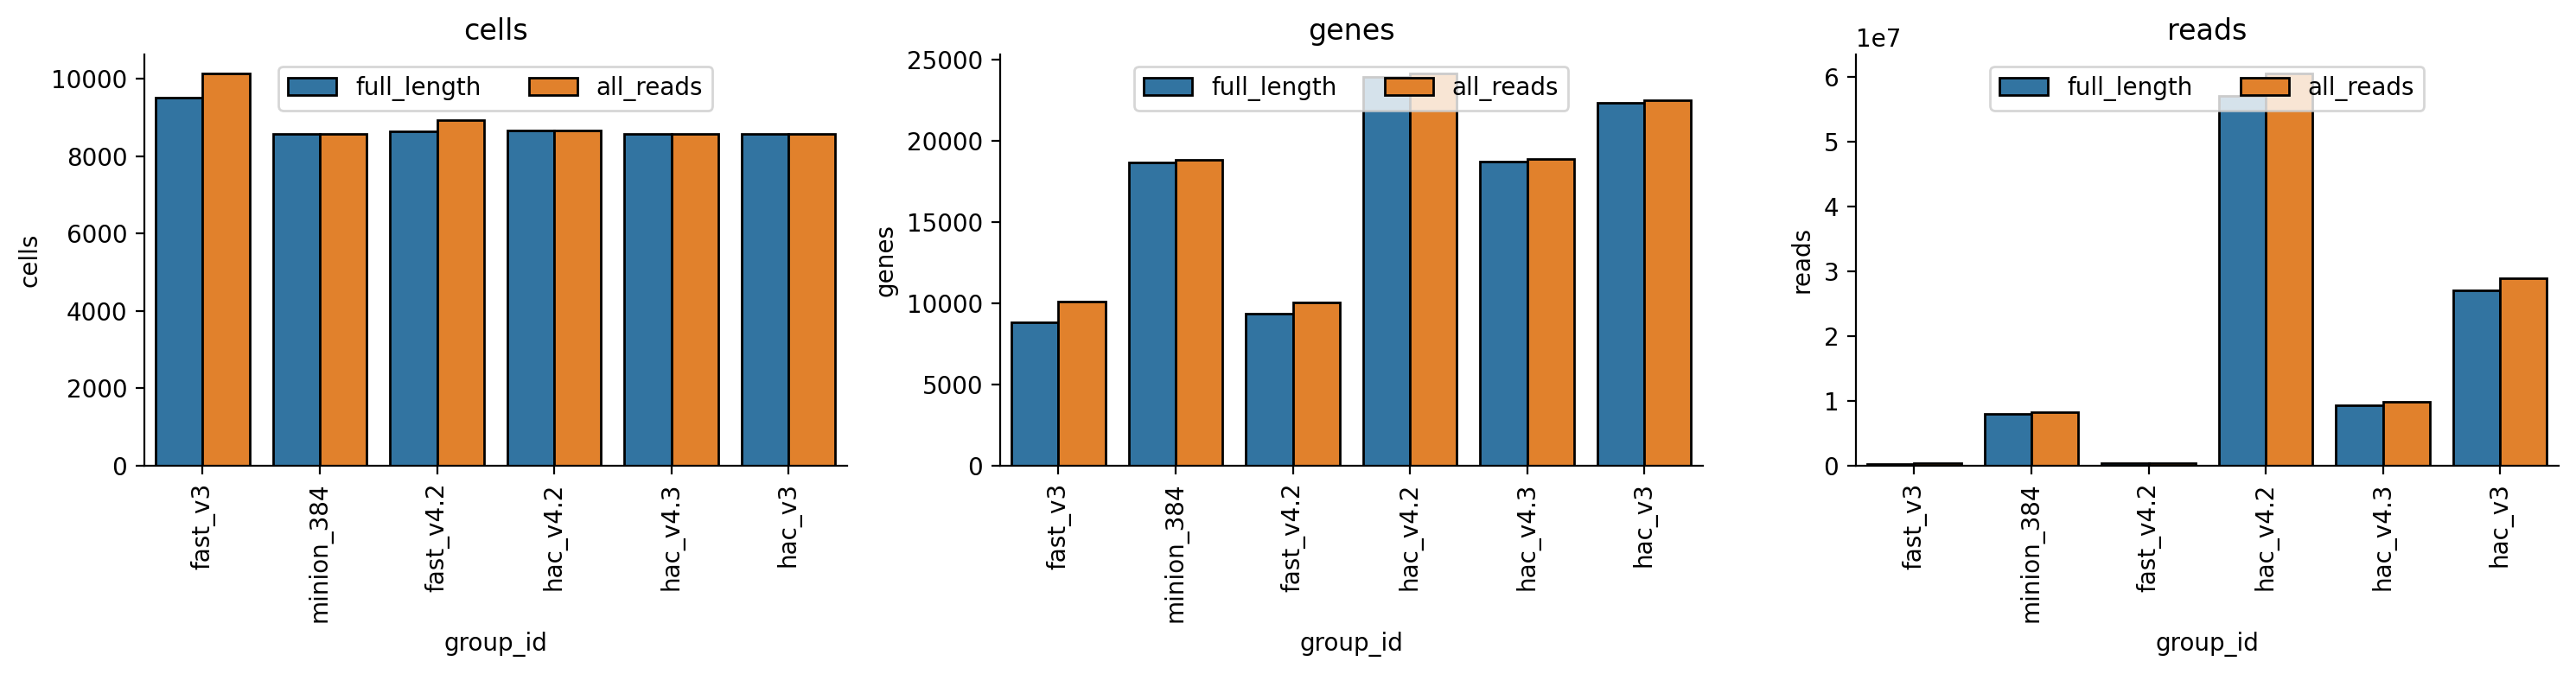

In [3]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 15, 4
fig, axs = plt.subplots(1, 3)
axs = axs.ravel()

for i, col in enumerate(['cells', 'genes', 'reads']):
    sns.barplot(
        data=results,
        x='group_id',
        y=col,
        ec='k',
        hue='key',
        ax=axs[i],
    )
    axs[i].tick_params(axis='x', rotation=90)
    sns.move_legend(
        axs[i],
        title="",
        loc='upper center',
        ncol=2
    )
    axs[i].set_title(col)

sns.despine()
plt.tight_layout()

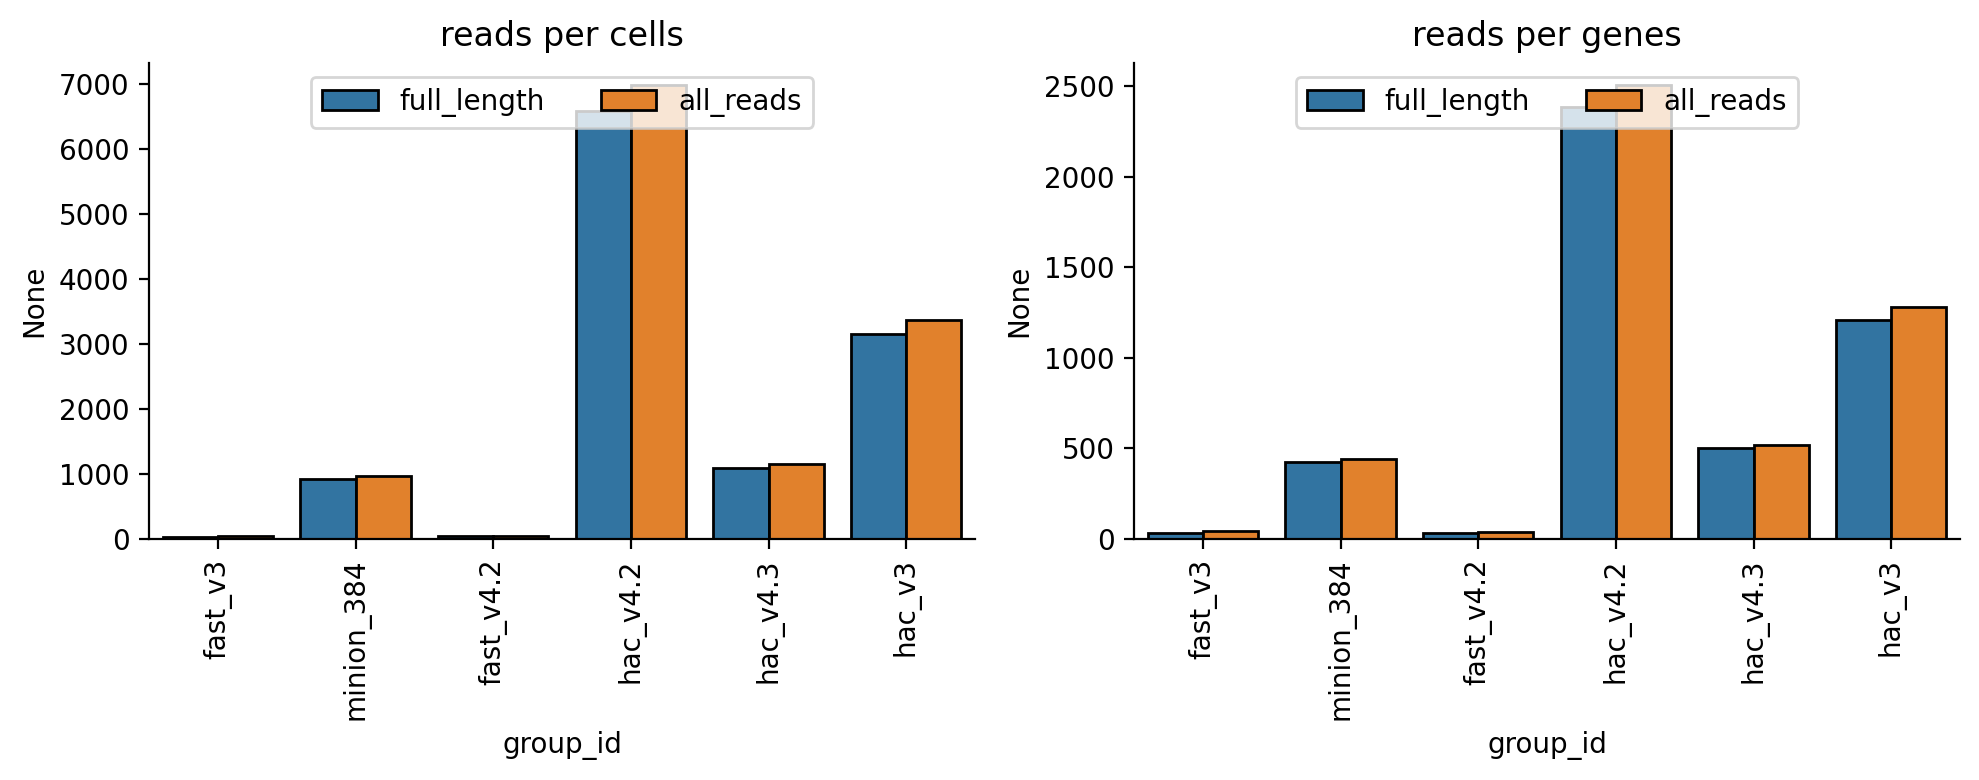

In [4]:
# reads per cell and reads per gene

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 10, 4
fig, axs = plt.subplots(1, 2)
axs = axs.ravel()

for i, col in enumerate(['cells', 'genes']):

    y = results['reads'] / results[col] 
    sns.barplot(
        data=results,
        x='group_id',
        y=y,
        ec='k',
        hue='key',
        ax=axs[i],
    )
    
    axs[i].tick_params(axis='x', rotation=90)
    sns.move_legend(
        axs[i],
        title="",
        loc='upper center',
        ncol=2
    )
    axs[i].set_title(f"reads per {col}")

sns.despine()
plt.tight_layout()

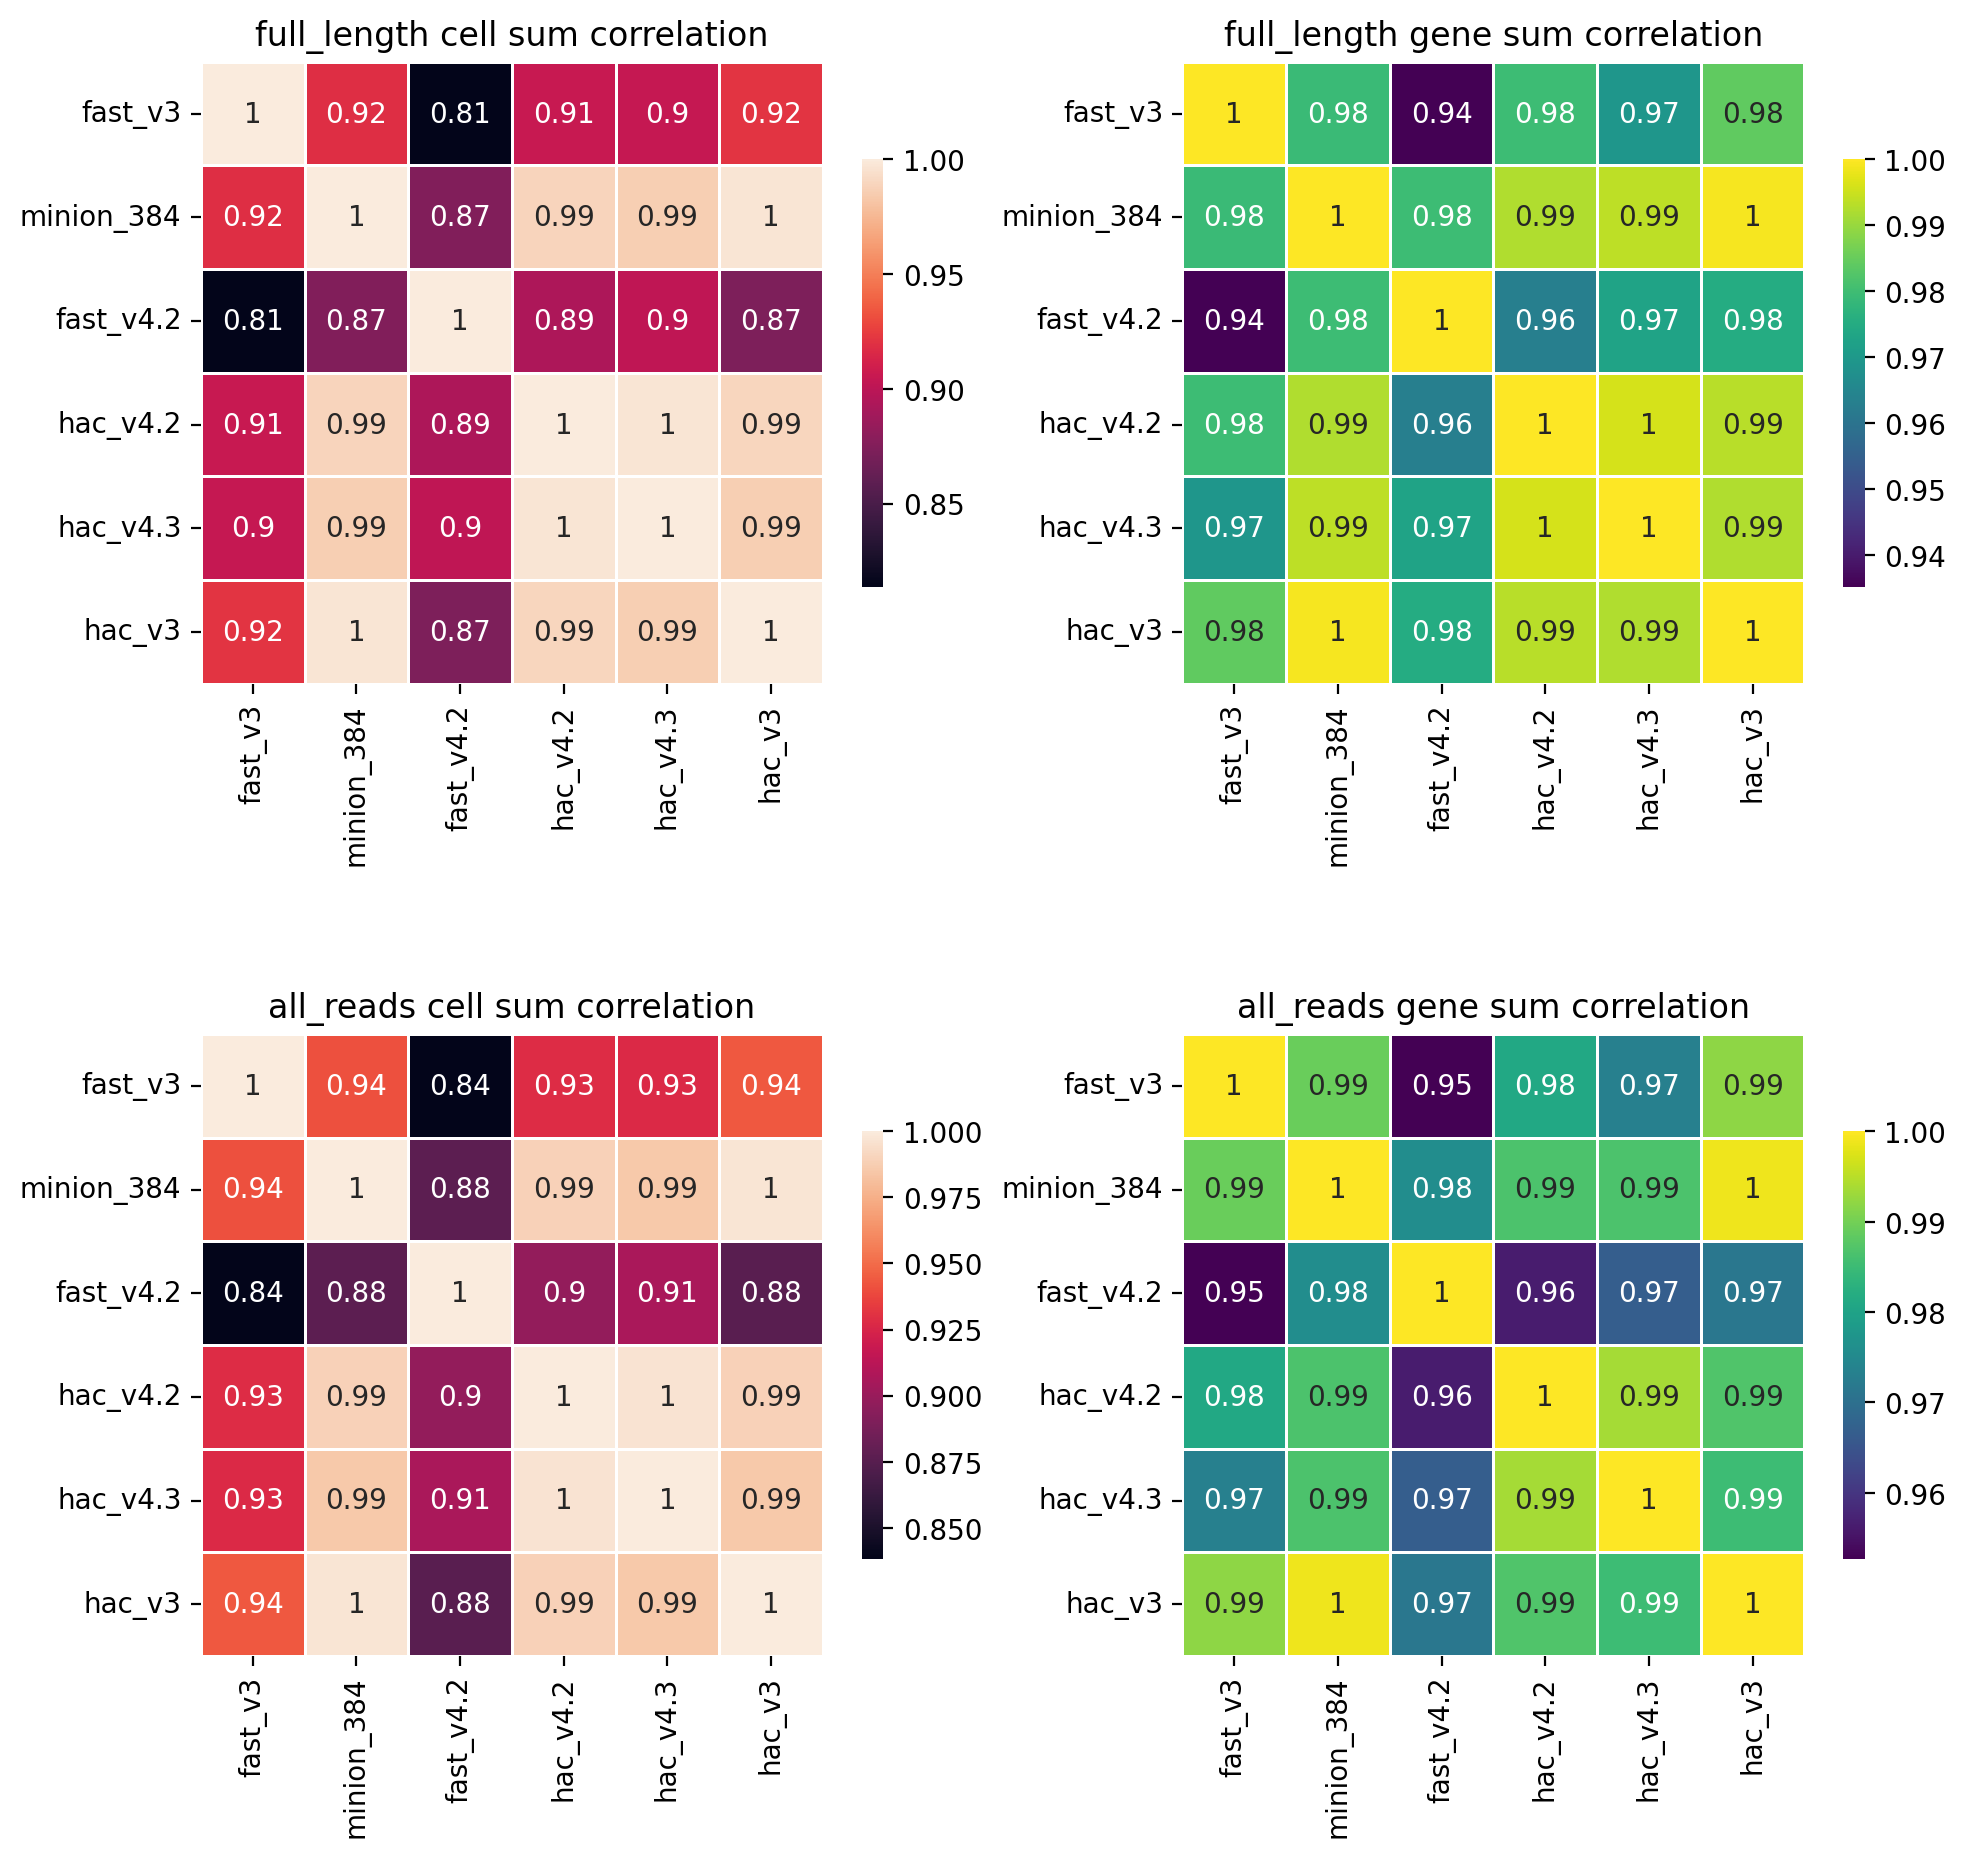

In [5]:
# correltion between total counts

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 10, 10
fig, axs = plt.subplots(2, 2)

for i, (key, sample_data) in enumerate(data.items()):

    cells = []
    genes = []
    
    for sample, df in sample_data.items():   
        row_sum = df.sum(axis=1)
        row_sum.name = sample
        cells.append(row_sum)

        col_sum = df.sum(axis=0)
        col_sum.name = sample
        genes.append(col_sum)

    cells = pd.concat(cells, ignore_index=False, axis=1)
    genes = pd.concat(genes, ignore_index=False, axis=1)

    sns.heatmap(
        data=cells.corr(),
        square=True,
        ax=axs[i, 0],
        lw=1,
        cbar_kws={'shrink' : 0.5},
        annot=True,
    )

    axs[i, 0].set_title(f"{key} cell sum correlation")

    sns.heatmap(
        data=genes.corr(),
        square=True,
        ax=axs[i, 1],
        lw=1,
        cbar_kws={'shrink' : 0.5},
        annot=True,
        cmap='viridis',
    )

    axs[i, 1].set_title(f"{key} gene sum correlation")
    
plt.tight_layout()

# Identify Genes with High Variability

In [6]:
for i, (key, sample_data) in enumerate(data.items()):
    print(key)
    genes = []
    for sample, df in sample_data.items():   
        col_sum = df.sum(axis=0)
        col_sum = col_sum / col_sum.sum() # normalize to sequencing depth 
        col_sum.name = sample
        genes.append(col_sum)

    genes = pd.concat(genes, ignore_index=False, axis=1)
    gene_var = genes.std(axis=1).sort_values(ascending=False)
    gene_var = pd.DataFrame(gene_var[gene_var.notna()], columns=['std'])
    gene_var['rank'] = gene_var['std'].rank(ascending=False)
    
    break 
    
gene_var.head(15)

full_length


,std,rank
S100A6,0.006701,1.0
FTL,0.002937,2.0
MT2A,0.002877,3.0
MALAT1,0.002211,4.0
TMSB10,0.001616,5.0
MT-CO2,0.001593,6.0
MT-ND3,0.001388,7.0
TIMP1,0.001329,8.0
RPL13,0.001223,9.0
FTH1,0.001137,10.0


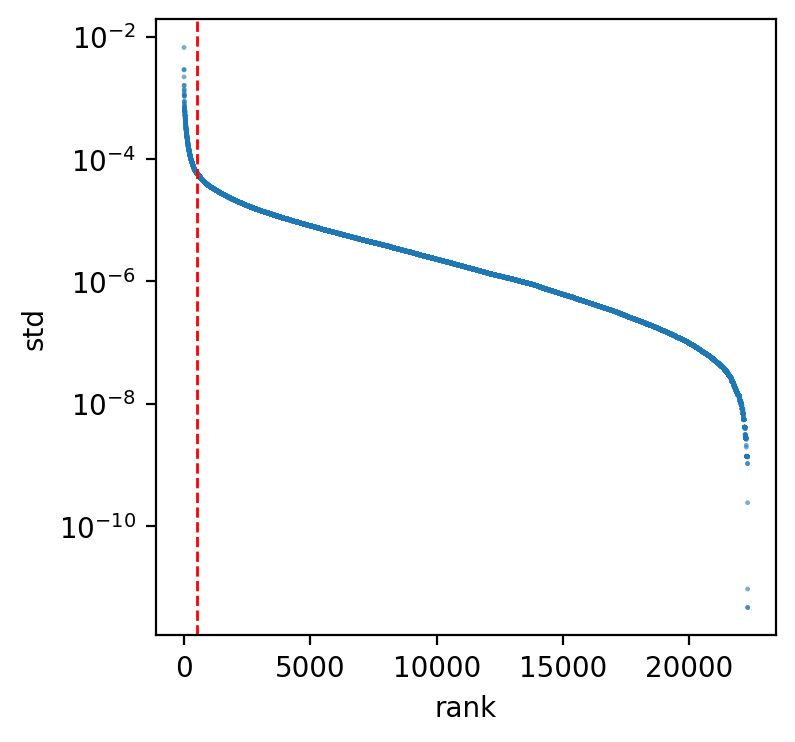

In [7]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4,4

sns.scatterplot(
    data=gene_var,
    x='rank',
    y='std',
    s=3,
    alpha=0.6,
    ec='none',
)

plt.axvline(x=500, c='r', ls="--", lw=1)
plt.yscale('log')
# plt.xscale('log')

In [8]:
database = 'ontology'
n_genes = 50

edf = gget.enrichr(
    gene_var.head(n_genes).index,
    database=database,
)

edf['n_genes'] = edf['overlapping_genes'].apply(len)

edf = edf[['path_name', 'adj_p_val', 'n_genes']]
print(edf.head(10).to_string(index=False))

Thu Apr 10 11:00:04 2025 INFO Performing Enichr analysis using database GO_Biological_Process_2021. 
    Please note that there might a more appropriate database for your application. 
    Go to https://maayanlab.cloud/Enrichr/#libraries for a full list of supported databases.
    


                                                                       path_name    adj_p_val  n_genes
        SRP-dependent cotranslational protein targeting to membrane (GO:0006614) 5.125065e-42       24
                      cotranslational protein targeting to membrane (GO:0006613) 8.481045e-42       24
                                            protein targeting to ER (GO:0045047) 6.818826e-41       24
nuclear-transcribed mRNA catabolic process, nonsense-mediated decay (GO:0000184) 6.167907e-40       24
                                            cytoplasmic translation (GO:0002181) 6.391097e-40       23
                                       peptide biosynthetic process (GO:0043043) 5.089052e-36       24
                         nuclear-transcribed mRNA catabolic process (GO:0000956) 1.743465e-35       24
                                                        translation (GO:0006412) 4.484986e-33       24
                                 cellular protein metabolic process (GO:0

Genes involved in translation (ribosomal proteins), targeting (signal sequences, receptors), and NMD (RNA binding proteins) can have numerous isoforms, alternative start/end sites, and sometimes pseudogenes. The ability of a specific ONT dataset (considering depth, read length, accuracy) and the chosen analysis pipeline to resolve this complexity accurately can vary, leading to different reported results for these specific genes.

In [9]:
database = 'ontology'
n_genes = 500

edf = gget.enrichr(
    gene_var.head(n_genes).index,
    database=database,
)

edf['n_genes'] = edf['overlapping_genes'].apply(len)

edf = edf[['path_name', 'adj_p_val', 'n_genes']]
print(edf.head(10).to_string(index=False))

Thu Apr 10 11:00:04 2025 INFO Performing Enichr analysis using database GO_Biological_Process_2021. 
    Please note that there might a more appropriate database for your application. 
    Go to https://maayanlab.cloud/Enrichr/#libraries for a full list of supported databases.
    


                                                                       path_name    adj_p_val  n_genes
        SRP-dependent cotranslational protein targeting to membrane (GO:0006614) 4.242022e-92       70
                                            cytoplasmic translation (GO:0002181) 1.458221e-90       70
                      cotranslational protein targeting to membrane (GO:0006613) 3.727517e-90       70
                                            protein targeting to ER (GO:0045047) 1.505956e-89       72
nuclear-transcribed mRNA catabolic process, nonsense-mediated decay (GO:0000184) 3.143161e-81       70
                                       peptide biosynthetic process (GO:0043043) 1.960384e-69       72
                                                        translation (GO:0006412) 8.876843e-69       79
                         nuclear-transcribed mRNA catabolic process (GO:0000956) 2.017129e-64       70
                        cellular macromolecule biosynthetic process (GO:0

In [10]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
dpath = "/scratch/indikar_root/indikar1/shared_data/hsc_epi2me_full/" # full length only reads included
# dpath = "/scratch/indikar_root/indikar1/shared_data/hsc_epi2me/" # all reads included

subdirs = glob.glob(f"{dpath}/*_*")

data = {}

for path in subdirs:
    group_id = path.split("/")[-1]
    mtx_path = os.path.join(path, f"{group_id}.gene_raw_feature_bc_matrix") # the gene-level matrices
    df = sc.read_10x_mtx(mtx_path).to_df()

    total_elements = df.size
    zero_sparsity = (df == 0).sum().sum() / total_elements
    
    print(f" ---- {group_id}  ---- ")
    print(f"\t{df.shape=}")
    print(f"\t{zero_sparsity=:.4f}")

    break
    
#     data[group_id] = df

# data.keys()

In [ ]:
df.head()